# ETF 动量 + R² 策略参数扫描回测

**策略逻辑：**
- 每隔 `rebal_period` 个交易日做一次调仓
- 调仓时，对每只 ETF 取过去 `n` 天的 log(收盘价)，做线性回归 log(P) = a + b·t
- 用 **斜率 b** 衡量动量强度，用 **R²** 衡量趋势质量
- 仅保留 R² ≥ 阈值的标的，从中选斜率最大的 top_k 只等权持有
- 若无标的通过筛选，该期空仓（收益为 0）

**扫描维度：** n (回看天数) × R² 阈值 × 调仓周期

In [10]:
import numpy as np
import pandas as pd
from pathlib import Path
from itertools import product
import warnings
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False
warnings.filterwarnings('ignore')

DB_DIR = Path('db')

## 1. 加载数据

In [11]:
closes = {}
opens = {}
for fp in sorted(DB_DIR.glob('*.csv')):
    df = pd.read_csv(fp, index_col=0, parse_dates=True)
    if not df.empty and 'Close' in df.columns and len(df) >= 30:
        closes[fp.stem] = df['Close']
        if 'Open' in df.columns:
            opens[fp.stem] = df['Open']

# ffill 填充交易日间隙（ETF 上市前仍为 NaN，不会被错误填充）
panel = pd.DataFrame(closes).sort_index().ffill()
panel_open = pd.DataFrame(opens).sort_index().ffill()
print(f'加载 {panel.shape[1]} 只 ETF，{panel.shape[0]} 个交易日')
print(f'日期范围: {panel.index[0].strftime("%Y-%m-%d")} ~ {panel.index[-1].strftime("%Y-%m-%d")}')

加载 177 只 ETF，2963 个交易日
日期范围: 2014-01-02 ~ 2026-03-13


## 2. 回测引擎

利用滚动窗口向量化计算线性回归的斜率和 R²，避免逐只逐日循环。

In [12]:
def rolling_linreg(log_close: pd.DataFrame, n: int):
    """对 log(close) 面板做滚动 n 日线性回归，返回 (slope, R²) 两个面板。

    数学模型: y = a + b*x，其中
      x = [0, 1, 2, ..., n-1]   （时间序号，固定）
      y = log(close) 的滚动窗口  （每天、每只 ETF 各一个窗口）

    用最小二乘解析公式（非迭代）一次性计算全部日期×全部ETF的 slope(b) 和 R²。

    slope > 0 表示该 ETF 在过去 n 天呈上涨趋势，slope 越大涨势越强。
    R² 接近 1 表示趋势非常线性（稳定上涨），R² 低表示波动大、趋势不稳。
    """
    # ── 解析公式所需的 x 侧常量（与数据无关，只取决于窗口长度 n）──
    # Σx = 0+1+...+(n-1) = n(n-1)/2
    sum_x = n * (n - 1) / 2
    # Σx² = 0²+1²+...+(n-1)² = n(n-1)(2n-1)/6
    sum_x2 = n * (n - 1) * (2 * n - 1) / 6
    # 分母 = n*Σx² - (Σx)²
    denom_x = n * sum_x2 - sum_x ** 2

    # x 权重向量 [0, 1, 2, ..., n-1]，用于计算 Σ(x*y)
    weights = np.arange(n, dtype=float)

    # ── 滚动计算 y 侧统计量（向量化，对全部 ETF 列同时计算）──
    # Σy: 窗口内 log(close) 的求和
    roll_sum_y = log_close.rolling(n).sum()
    # Σy²: 窗口内 log(close)² 的求和
    roll_sum_y2 = (log_close ** 2).rolling(n).sum()
    # Σ(x*y): 窗口内 x[i]*y[i] 的求和，等价于 dot([0,1,...,n-1], window)
    roll_sum_xy = log_close.rolling(n).apply(lambda w: np.dot(weights, w), raw=True)

    # ── 最小二乘斜率 b = (n*Σxy - Σx*Σy) / (n*Σx² - (Σx)²) ──
    slope = (n * roll_sum_xy - sum_x * roll_sum_y) / denom_x

    # ── R² = SS_reg / SS_tot ──
    # SS_tot = n*Σy² - (Σy)²  （总离差平方和 × n，等比例不影响 R²）
    ss_tot = n * roll_sum_y2 - roll_sum_y ** 2
    # SS_reg = (n*Σxy - Σx*Σy)² / (n*Σx² - (Σx)²)  （回归平方和 × n）
    ss_reg = (n * roll_sum_xy - sum_x * roll_sum_y) ** 2 / denom_x
    # R² = SS_reg / SS_tot，SS_tot=0 时设为 NaN，最终 clip 到 [0,1]
    r2 = ss_reg / ss_tot.replace(0, np.nan)
    r2 = r2.clip(0, 1)

    return slope, r2


# ══════════════════════════════════════════════════════════════════════
# 交易成本参数
# ══════════════════════════════════════════════════════════════════════
SLIPPAGE = 0.001       # 滑点 0.1%: 买入价 = open*(1+0.001)，卖出价 = open*(1-0.001)
COMMISSION = 0.00006   # 单边手续费 0.006%（买一次扣一次，卖一次扣一次）

# ══════════════════════════════════════════════════════════════════════
# 预计算中间量（后续所有参数组合的回测复用，不重复计算）
# ══════════════════════════════════════════════════════════════════════
# log_close: 对收盘价取自然对数，用于线性回归（log空间下的线性=价格空间下的指数增长）
log_close = np.log(panel.replace(0, np.nan))
# daily_ret: 每日收益率 = (close[t] - close[t-1]) / close[t-1]
daily_ret = panel.pct_change()
# linreg_cache: {n: (slope_df, r2_df)}，对每个 n 只计算一次
linreg_cache = {}

def precompute_linreg(n_list):
    """对所有 n 值预计算 slope / R²，缓存到 linreg_cache。"""
    for n in n_list:
        if n not in linreg_cache:
            linreg_cache[n] = rolling_linreg(log_close, n)
            print(f'  预计算 rolling_linreg(n={n}) 完成')


# ══════════════════════════════════════════════════════════════════════
# 核心回测函数
# ══════════════════════════════════════════════════════════════════════
def backtest_momentum(
    slope: pd.DataFrame,
    r2: pd.DataFrame,
    daily_ret: pd.DataFrame,
    n: int,
    r2_threshold: float,
    rebal_period: int,
    top_k: int = 1,
    slippage: float = SLIPPAGE,
    commission: float = COMMISSION,
    take_profit: float = None,
    max_dd_stop: float = None,
) -> pd.Series:
    """基于预计算的 slope/R² 运行回测，返回每日净值序列。

    take_profit: 单笔止盈阈值（如 0.2=20%），持仓累计收益达标后平仓转现金至下次调仓。None=不限。
    max_dd_stop: 单笔回撤止损阈值（如 0.1=10%），持仓从峰值回撤达标后平仓转现金至下次调仓。None=不限。
    两者均为逐笔独立判断，不影响其他持仓。
    """

    start_idx = n + 5
    dates = daily_ret.index[start_idx:]
    rebal_indices = list(range(0, len(dates), rebal_period))

    signal_map = {}
    for idx_pos in rebal_indices:
        date = dates[idx_pos]
        s = slope.loc[date].dropna()
        r = r2.loc[date].dropna()
        common = s.index.intersection(r.index)
        s, r = s[common], r[common]
        candidates = s[r >= r2_threshold].sort_values(ascending=False)
        selected = candidates.head(top_k).index.tolist() if len(candidates) >= 1 else []
        signal_map[idx_pos] = selected

    exec_map = {}
    for sig_idx, selected in signal_map.items():
        exec_idx = sig_idx + 1
        if exec_idx < len(dates):
            exec_map[exec_idx] = selected

    cum = 1.0
    nav_values = np.ones(len(dates))
    current_holdings = []
    entry_prices = {}
    position_alive = {}
    position_peak = {}

    for d in range(len(dates)):
        date = dates[d]

        if d in exec_map:
            new_holdings = exec_map[d]
            any_dead = any(not position_alive.get(s, True) for s in current_holdings)
            positions_changed = (sorted(new_holdings) != sorted(current_holdings)
                                 or any_dead)

            if positions_changed:
                if current_holdings and d > 0:
                    prev_date = dates[d - 1]
                    alive_old = [s for s in current_holdings if position_alive.get(s, True)]
                    k_sell = len(alive_old)
                    if k_sell > 0:
                        sell_rets = []
                        for sym in alive_old:
                            prev_cl = panel.loc[prev_date, sym]
                            op = panel_open.loc[date, sym] if (date in panel_open.index and sym in panel_open.columns) else panel.loc[date, sym]
                            sell_price = op * (1 - slippage)
                            sell_rets.append(sell_price / prev_cl - 1)
                        portfolio_sell_ret = np.nansum(sell_rets) / top_k
                        cum *= (1 + portfolio_sell_ret)
                        cum *= (1 - k_sell / top_k * commission)

                entry_prices = {}
                position_peak = {}
                if new_holdings:
                    k_buy = len(new_holdings)
                    cum *= (1 - k_buy / top_k * commission)
                    buy_rets = []
                    for sym in new_holdings:
                        op = panel_open.loc[date, sym] if (date in panel_open.index and sym in panel_open.columns) else panel.loc[date, sym]
                        buy_price = op * (1 + slippage)
                        cl = panel.loc[date, sym]
                        entry_prices[sym] = buy_price
                        position_peak[sym] = cl
                        buy_rets.append(cl / buy_price - 1)
                    portfolio_buy_ret = np.nansum(buy_rets) / top_k
                    cum *= (1 + portfolio_buy_ret)

                current_holdings = new_holdings
                position_alive = {s: True for s in new_holdings}
            else:
                if current_holdings:
                    alive_syms = [s for s in current_holdings if position_alive.get(s, True)]
                    if alive_syms:
                        rets = daily_ret.loc[date, alive_syms]
                        portfolio_ret = np.nansum(rets.values) / top_k
                        cum *= (1 + portfolio_ret)
        else:
            if current_holdings:
                alive_syms = [s for s in current_holdings if position_alive.get(s, True)]
                if alive_syms:
                    rets = daily_ret.loc[date, alive_syms]
                    portfolio_ret = np.nansum(rets.values) / top_k
                    cum *= (1 + portfolio_ret)

        # 逐笔止盈：持仓累计收益 >= take_profit → 平仓该笔
        if take_profit is not None and current_holdings:
            for sym in current_holdings:
                if position_alive.get(sym, False) and sym in entry_prices:
                    current_price = panel.loc[date, sym]
                    if current_price / entry_prices[sym] - 1 >= take_profit:
                        position_alive[sym] = False
                        cum *= (1 - 1 / top_k * commission)

        # 逐笔止损：持仓从峰值回撤 >= max_dd_stop → 平仓该笔
        if max_dd_stop is not None and current_holdings:
            for sym in current_holdings:
                if position_alive.get(sym, False) and sym in position_peak:
                    current_price = panel.loc[date, sym]
                    if current_price > position_peak[sym]:
                        position_peak[sym] = current_price
                    if 1 - current_price / position_peak[sym] >= max_dd_stop:
                        position_alive[sym] = False
                        cum *= (1 - 1 / top_k * commission)

        nav_values[d] = cum

    return pd.Series(nav_values, index=dates, name='NAV')

## 3. 定义参数网格

In [5]:
N_LIST = [3, 5, 7, 20, 25, 30, 35, 40]           # 动量回看天数 (移除表现差的10,15; 补充7,35)
R2_LIST = [0.3, 0.5, 0.6, 0.7, 0.8]               # R² 阈值 (移除0.4≈0.3、0.9最差)
REBAL_LIST = [10, 15, 20, 25, 30, 45, 60]          # 调仓周期 (移除5最差; 补充25,45,60)
TOP_K_LIST = [1, 2, 3]                             # 每次持有 ETF 数量 (移除5收益最低)
TP_LIST = [0.2, 0.3, 0.5, None]                    # 单笔止盈 (None=不限)
SL_DD_LIST = [0.1, 0.2, 0.3, None]                 # 最大回撤止损 (None=不限)

param_grid = list(product(N_LIST, R2_LIST, REBAL_LIST, TOP_K_LIST, TP_LIST, SL_DD_LIST))
print(f'参数组合数: {len(param_grid)}  ({len(N_LIST)}n × {len(R2_LIST)}R² × {len(REBAL_LIST)}rebal × {len(TOP_K_LIST)}topk × {len(TP_LIST)}TP × {len(SL_DD_LIST)}SL)')

参数组合数: 13440  (8n × 5R² × 7rebal × 3topk × 4TP × 4SL)


## 4. 批量回测

In [5]:
import time as _time
import multiprocessing as _mp
from concurrent.futures import ProcessPoolExecutor as _PPE
import os as _os

# 预计算所有 n 值的线性回归（最耗时步骤，每个 n 只算一次）
print('预计算 rolling linreg ...')
precompute_linreg(N_LIST)

_NUM_WORKERS = max(1, _os.cpu_count() - 1)

def _bt_one(params):
    """单组参数的回测 + 绩效指标计算（12年全量）。"""
    n, r2_thresh, rebal, top_k, tp, sl_dd = params
    slope, r2 = linreg_cache[n]
    nav = backtest_momentum(slope, r2, daily_ret, n=n, r2_threshold=r2_thresh,
                            rebal_period=rebal, top_k=top_k,
                            take_profit=tp, max_dd_stop=sl_dd)

    tp_s = 'inf' if tp is None else str(tp)
    sl_s = 'inf' if sl_dd is None else str(sl_dd)
    label = f'n={n}_R2={r2_thresh}_rebal={rebal}_topk={top_k}_tp={tp_s}_sl={sl_s}'

    years = sorted(nav.index.year.unique())
    annual_rets = {}
    for yr in years:
        yr_nav = nav[nav.index.year == yr]
        if len(yr_nav) < 10:
            continue
        annual_rets[yr] = yr_nav.iloc[-1] / yr_nav.iloc[0] - 1

    full_years = [y for y in annual_rets if y != years[0] and y != years[-1]]
    avg_ret = np.mean([annual_rets[y] for y in full_years]) if full_years else np.nan

    total_ret = nav.iloc[-1] / nav.iloc[0] - 1
    n_years = (nav.index[-1] - nav.index[0]).days / 365.25
    annualized = (1 + total_ret) ** (1 / n_years) - 1 if n_years > 0 else np.nan
    max_dd = ((nav / nav.cummax()) - 1).min()
    dr = nav.pct_change().dropna()
    sharpe = (dr.mean() / dr.std() * np.sqrt(252)) if dr.std() > 0 else np.nan

    row = {'n': n, 'R2_threshold': r2_thresh, 'rebal_period': rebal, 'top_k': top_k,
           'take_profit': tp, 'max_dd_stop': sl_dd}
    row.update(annual_rets)
    row['avg_full_year'] = avg_ret
    row['annualized'] = annualized
    row['total_ret'] = total_ret
    row['sharpe'] = sharpe
    row['max_drawdown'] = max_dd
    return label, nav, row

# ─── 12 年全量回测 ───
print(f'使用 {_NUM_WORKERS} 个进程并行回测 {len(param_grid)} 组参数（12年全量）...')
t0 = _time.time()
_ctx = _mp.get_context('fork')
with _PPE(max_workers=_NUM_WORKERS, mp_context=_ctx) as executor:
    _all_results = list(executor.map(_bt_one, param_grid, chunksize=40))

results_12y = []
nav_cache = {}
for label, nav, row in _all_results:
    nav_cache[label] = nav
    results_12y.append(row)
elapsed_12y = _time.time() - t0
print(f'12年回测完成，共 {len(results_12y)} 组参数，耗时 {elapsed_12y:.1f}s')

# ─── 近 3 年数据与预计算 ───
panel_3y = panel.loc[panel.index >= panel.index[-1] - pd.DateOffset(years=3)]
panel_open_3y = panel_open.reindex(panel_3y.index).ffill().bfill()
log_close_3y = np.log(panel_3y.replace(0, np.nan))
daily_ret_3y = panel_3y.pct_change()
linreg_cache_3y = {}
for n in N_LIST:
    linreg_cache_3y[n] = rolling_linreg(log_close_3y, n)
print('近3年 rolling_linreg 预计算完成')

def _bt_one_3y(params):
    """单组参数的 3 年回测。"""
    n, r2_thresh, rebal, top_k, tp, sl_dd = params
    slope_3y, r2_3y = linreg_cache_3y[n]
    nav = backtest_momentum(slope_3y, r2_3y, daily_ret_3y, n=n, r2_threshold=r2_thresh,
                            rebal_period=rebal, top_k=top_k,
                            take_profit=tp, max_dd_stop=sl_dd)

    tp_s = 'inf' if tp is None else str(tp)
    sl_s = 'inf' if sl_dd is None else str(sl_dd)
    label = f'n={n}_R2={r2_thresh}_rebal={rebal}_topk={top_k}_tp={tp_s}_sl={sl_s}'

    years = sorted(nav.index.year.unique())
    annual_rets = {}
    for yr in years:
        yr_nav = nav[nav.index.year == yr]
        if len(yr_nav) < 10:
            continue
        annual_rets[yr] = yr_nav.iloc[-1] / yr_nav.iloc[0] - 1
    full_years = [y for y in annual_rets if y != years[0] and y != years[-1]]
    avg_ret = np.mean([annual_rets[y] for y in full_years]) if full_years else np.nan
    total_ret = nav.iloc[-1] / nav.iloc[0] - 1
    n_years = (nav.index[-1] - nav.index[0]).days / 365.25
    annualized = (1 + total_ret) ** (1 / n_years) - 1 if n_years > 0 else np.nan
    max_dd = ((nav / nav.cummax()) - 1).min()
    dr = nav.pct_change().dropna()
    sharpe = (dr.mean() / dr.std() * np.sqrt(252)) if dr.std() > 0 else np.nan
    row = {'n': n, 'R2_threshold': r2_thresh, 'rebal_period': rebal, 'top_k': top_k,
           'take_profit': tp, 'max_dd_stop': sl_dd}
    row.update(annual_rets)
    row['avg_full_year'] = avg_ret
    row['annualized'] = annualized
    row['total_ret'] = total_ret
    row['sharpe'] = sharpe
    row['max_drawdown'] = max_dd
    return label, nav, row

# ─── 3 年回测 ───
print(f'使用 {_NUM_WORKERS} 个进程并行回测 {len(param_grid)} 组参数（近3年）...')
t0 = _time.time()
with _PPE(max_workers=_NUM_WORKERS, mp_context=_ctx) as executor:
    _all_3y = list(executor.map(_bt_one_3y, param_grid, chunksize=40))

results_3y = []
nav_cache_3y = {}
for label, nav, row in _all_3y:
    nav_cache_3y[label] = nav
    results_3y.append(row)
elapsed_3y = _time.time() - t0
print(f'近3年回测完成，共 {len(results_3y)} 组参数，耗时 {elapsed_3y:.1f}s')

# ─── 合并为同一表格 ───
def _merge_row(r12, r3):
    year_cols_12y = [c for c in r12 if isinstance(c, (int, np.integer))]
    out = {'n': r12['n'], 'R2_threshold': r12['R2_threshold'],
           'rebal_period': r12['rebal_period'], 'top_k': r12['top_k'],
           'take_profit': r12['take_profit'], 'max_dd_stop': r12['max_dd_stop']}
    for c in year_cols_12y:
        out[c] = r12[c]
    out['avg_full_year_12y'] = r12['avg_full_year']
    out['annualized_12y'] = r12['annualized']
    out['total_ret_12y'] = r12['total_ret']
    out['sharpe_12y'] = r12['sharpe']
    out['max_drawdown_12y'] = r12['max_drawdown']
    year_cols_3y = [c for c in r3 if isinstance(c, (int, np.integer))]
    for c in year_cols_3y:
        out[f'y{c}_3y'] = r3[c]
    out['annualized_3y'] = r3['annualized']
    out['total_ret_3y'] = r3['total_ret']
    out['sharpe_3y'] = r3['sharpe']
    out['max_drawdown_3y'] = r3['max_drawdown']
    return out

results = [_merge_row(r12, r3) for r12, r3 in zip(results_12y, results_3y)]
print(f'\n合并完成，共 {len(results)} 组参数（12年+3年同表）')

预计算 rolling linreg ...
  预计算 rolling_linreg(n=3) 完成
  预计算 rolling_linreg(n=5) 完成
  预计算 rolling_linreg(n=7) 完成
  预计算 rolling_linreg(n=20) 完成
  预计算 rolling_linreg(n=25) 完成
  预计算 rolling_linreg(n=30) 完成
  预计算 rolling_linreg(n=35) 完成
  预计算 rolling_linreg(n=40) 完成
使用 7 个进程并行回测 13440 组参数（12年全量）...
12年回测完成，共 13440 组参数，耗时 6083.1s
近3年 rolling_linreg 预计算完成
使用 7 个进程并行回测 13440 组参数（近3年）...
近3年回测完成，共 13440 组参数，耗时 1098.8s

合并完成，共 13440 组参数（12年+3年同表）


## 5. 结果总览

In [6]:
result_df = pd.DataFrame(results)
result_df.to_csv('backtest_result.csv', index=False, encoding='utf-8-sig')
print(f'已导出 backtest_result.csv（共 {len(result_df)} 条，含 12 年 + 3 年指标）')

year_cols = [c for c in result_df.columns if isinstance(c, (int, np.integer))]
fmt_cols = year_cols + ['avg_full_year_12y', 'annualized_12y', 'total_ret_12y', 'sharpe_12y', 'max_drawdown_12y',
                        'annualized_3y', 'total_ret_3y', 'sharpe_3y', 'max_drawdown_3y']
fmt_cols = [c for c in fmt_cols if c in result_df.columns]

display_df = result_df.copy()
display_df['take_profit'] = display_df['take_profit'].map(lambda x: f'{x:.0%}' if pd.notna(x) else '不限')
display_df['max_dd_stop'] = display_df['max_dd_stop'].map(lambda x: f'{x:.0%}' if pd.notna(x) else '不限')
for c in fmt_cols:
    if c in display_df.columns:
        if 'sharpe' in str(c):
            display_df[c] = display_df[c].map(lambda x: f'{x:.2f}' if pd.notna(x) else '-')
        else:
            display_df[c] = display_df[c].map(lambda x: f'{x:.2%}' if pd.notna(x) else '-')

display_df = display_df.sort_values('annualized_12y', ascending=False, key=lambda s: result_df['annualized_12y'])

print('所有参数组合回测结果（按 12 年年化收益排序，前 30 条）:')
display(display_df.head(30))

已导出 backtest_result.csv（共 13440 条，含 12 年 + 3 年指标）
所有参数组合回测结果（按 12 年年化收益排序，前 30 条）:


,n,R2_threshold,rebal_period,top_k,take_profit,max_dd_stop,2014,2015,2016,2017,...,sharpe_12y,max_drawdown_12y,y2023_3y,y2024_3y,y2025_3y,y2026_3y,annualized_3y,total_ret_3y,sharpe_3y,max_drawdown_3y
2221,5,0.5,30,1,不限,20%,155.42%,68.96%,4.56%,24.00%,...,1.13,-35.86%,0.089771,-0.312852,-0.155715,0.188114,-7.96%,-21.77%,-0.08,-57.24%
1885,5,0.3,30,1,不限,20%,136.94%,94.10%,21.68%,18.77%,...,1.12,-35.86%,0.089771,-0.301386,0.308359,0.188114,7.31%,23.25%,0.38,-53.59%
2217,5,0.5,30,1,50%,20%,148.62%,68.52%,4.56%,24.00%,...,1.13,-35.86%,0.089771,-0.312852,-0.155715,0.113060,-9.96%,-26.72%,-0.14,-57.24%
1881,5,0.3,30,1,50%,20%,130.63%,93.60%,21.68%,18.77%,...,1.11,-35.86%,0.089771,-0.301386,0.296245,0.113060,4.64%,14.39%,0.31,-53.59%
537,3,0.5,30,1,50%,20%,119.78%,36.34%,3.50%,3.02%,...,1.07,-45.05%,-0.240634,-0.396858,0.554492,0.474423,3.52%,10.84%,0.27,-63.23%
533,3,0.5,30,1,30%,20%,68.90%,57.17%,3.50%,3.02%,...,1.11,-40.64%,-0.240634,-0.396858,0.338830,0.098984,-10.81%,-28.85%,-0.22,-63.23%
2222,5,0.5,30,1,不限,30%,155.42%,57.37%,4.56%,24.00%,...,1.10,-35.86%,0.089771,-0.312852,-0.155715,0.193425,-7.82%,-21.42%,-0.06,-57.24%
1886,5,0.3,30,1,不限,30%,136.94%,80.79%,21.68%,18.77%,...,1.08,-35.86%,0.089771,-0.301386,0.308359,0.193425,7.47%,23.80%,0.39,-53.59%
541,3,0.5,30,1,不限,20%,130.31%,37.84%,3.50%,3.02%,...,1.05,-45.05%,-0.240634,-0.396858,0.435735,0.188114,-6.27%,-17.51%,-0.03,-63.23%
2218,5,0.5,30,1,50%,30%,148.62%,56.96%,4.56%,24.00%,...,1.10,-35.86%,0.089771,-0.312852,-0.155715,0.118036,-9.83%,-26.39%,-0.13,-57.24%


## 6. 按维度影响图（12年 vs 3年）

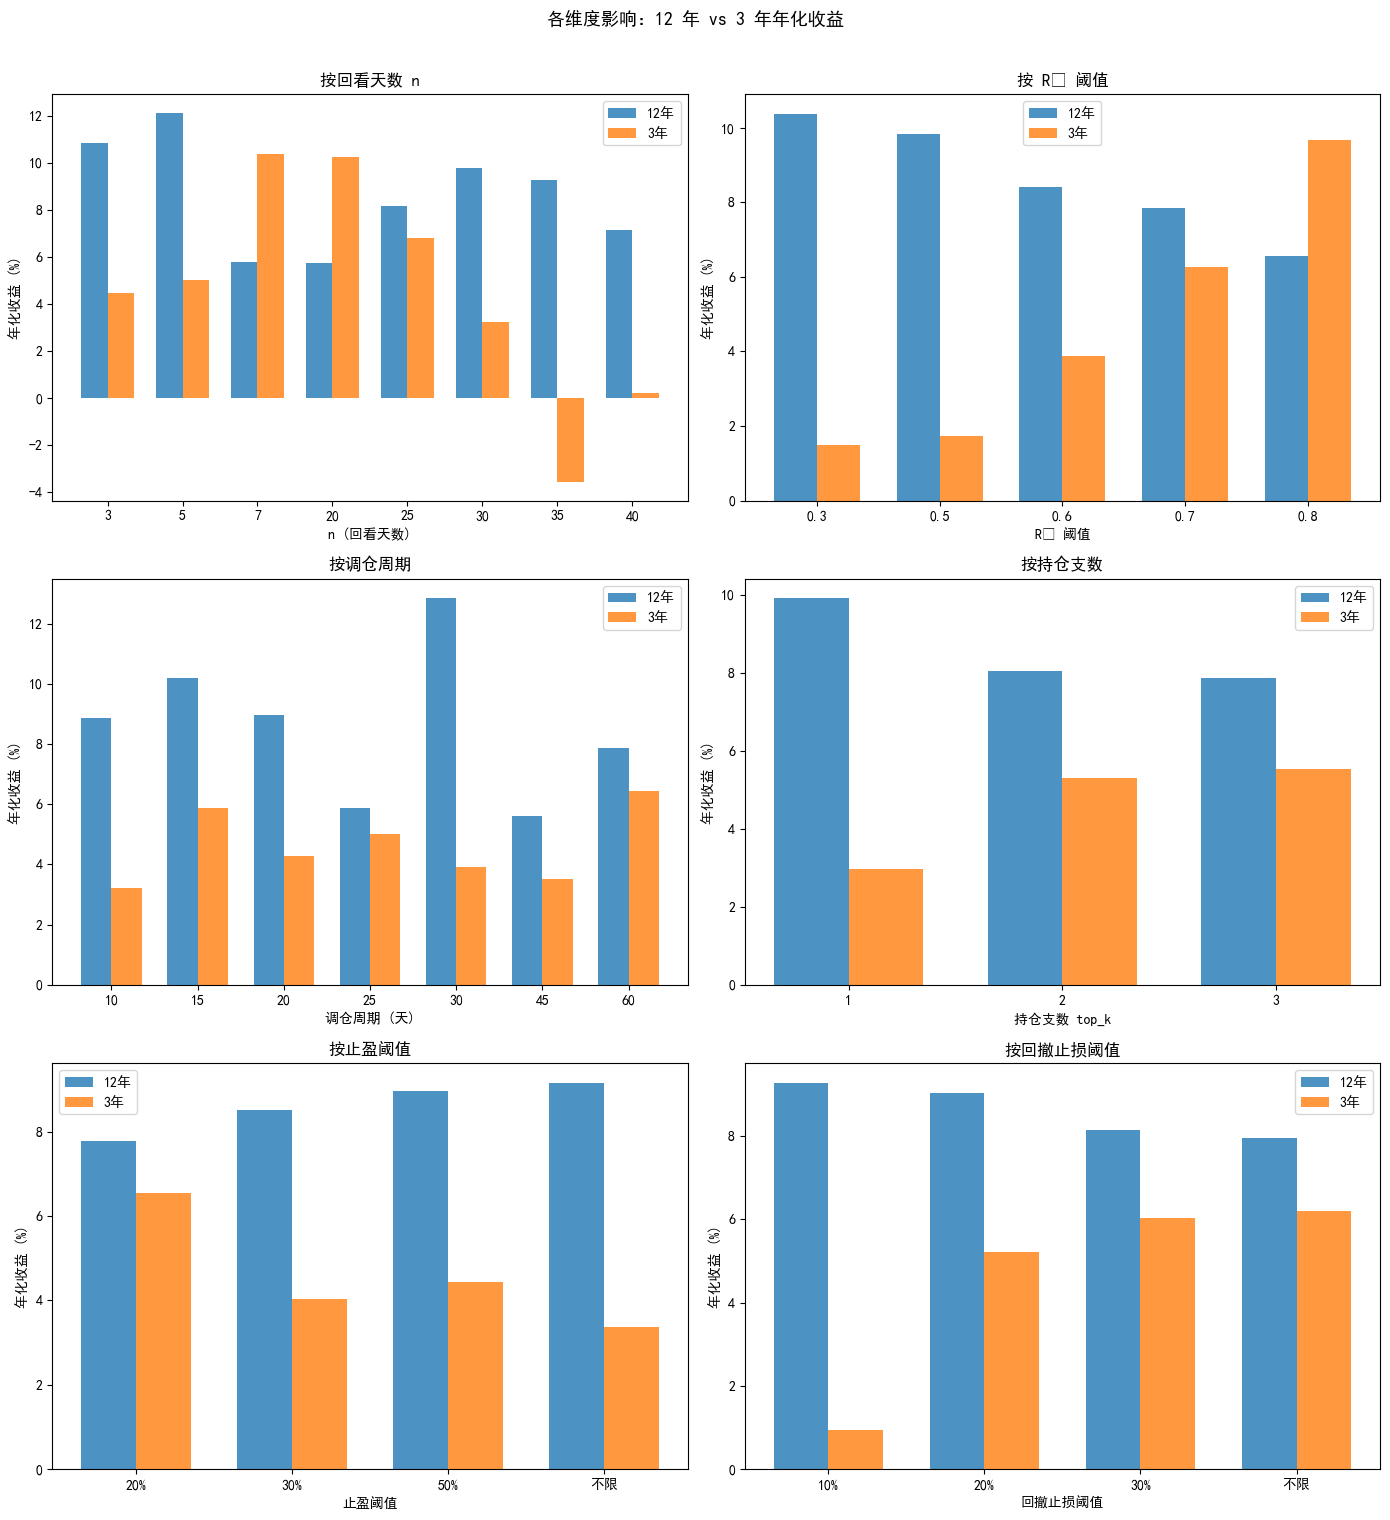

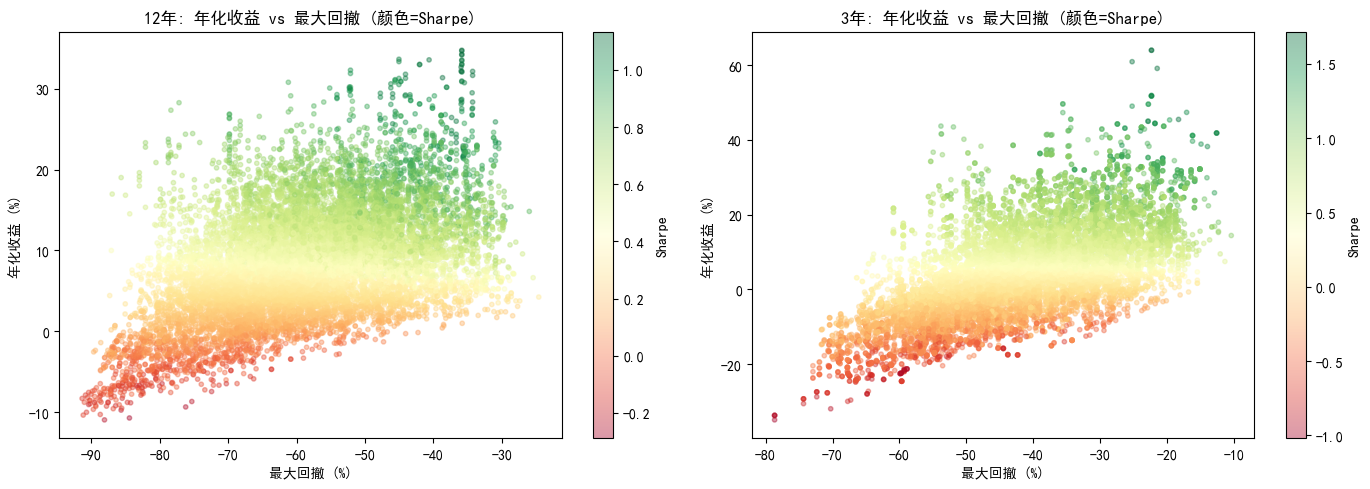

In [ ]:


fig, axes = plt.subplots(3, 2, figsize=(14, 15))
w = 0.35

# ── n ──
by_n_12 = result_df.groupby('n')['annualized_12y'].mean() * 100
by_n_3 = result_df.groupby('n')['annualized_3y'].mean() * 100
x = np.arange(len(by_n_12))
axes[0, 0].bar(x - w/2, by_n_12.values, w, label='12年', alpha=0.8)
axes[0, 0].bar(x + w/2, by_n_3.values, w, label='3年', alpha=0.8)
axes[0, 0].set_xticks(x); axes[0, 0].set_xticklabels(by_n_12.index.astype(str))
axes[0, 0].set_xlabel('n (回看天数)'); axes[0, 0].set_ylabel('年化收益 (%)')
axes[0, 0].set_title('按回看天数 n'); axes[0, 0].legend()

# ── R² ──
by_r2_12 = result_df.groupby('R2_threshold')['annualized_12y'].mean() * 100
by_r2_3 = result_df.groupby('R2_threshold')['annualized_3y'].mean() * 100
x2 = np.arange(len(by_r2_12))
axes[0, 1].bar(x2 - w/2, by_r2_12.values, w, label='12年', alpha=0.8)
axes[0, 1].bar(x2 + w/2, by_r2_3.values, w, label='3年', alpha=0.8)
axes[0, 1].set_xticks(x2); axes[0, 1].set_xticklabels([f'{v:.1f}' for v in by_r2_12.index])
axes[0, 1].set_xlabel('R² 阈值'); axes[0, 1].set_ylabel('年化收益 (%)')
axes[0, 1].set_title('按 R² 阈值'); axes[0, 1].legend()

# ── rebal ──
by_r_12 = result_df.groupby('rebal_period')['annualized_12y'].mean() * 100
by_r_3 = result_df.groupby('rebal_period')['annualized_3y'].mean() * 100
x3 = np.arange(len(by_r_12))
axes[1, 0].bar(x3 - w/2, by_r_12.values, w, label='12年', alpha=0.8)
axes[1, 0].bar(x3 + w/2, by_r_3.values, w, label='3年', alpha=0.8)
axes[1, 0].set_xticks(x3); axes[1, 0].set_xticklabels(by_r_12.index.astype(str))
axes[1, 0].set_xlabel('调仓周期 (天)'); axes[1, 0].set_ylabel('年化收益 (%)')
axes[1, 0].set_title('按调仓周期'); axes[1, 0].legend()

# ── top_k ──
by_k_12 = result_df.groupby('top_k')['annualized_12y'].mean() * 100
by_k_3 = result_df.groupby('top_k')['annualized_3y'].mean() * 100
x4 = np.arange(len(by_k_12))
axes[1, 1].bar(x4 - w/2, by_k_12.values, w, label='12年', alpha=0.8)
axes[1, 1].bar(x4 + w/2, by_k_3.values, w, label='3年', alpha=0.8)
axes[1, 1].set_xticks(x4); axes[1, 1].set_xticklabels(by_k_12.index.astype(str))
axes[1, 1].set_xlabel('持仓支数 top_k'); axes[1, 1].set_ylabel('年化收益 (%)')
axes[1, 1].set_title('按持仓支数'); axes[1, 1].legend()

# ── take_profit ──
tp_df = result_df.copy()
tp_df['tp_label'] = tp_df['take_profit'].map(lambda x: f'{x:.0%}' if pd.notna(x) else '不限')
tp_order = ['20%', '30%', '50%', '不限']
tp_grp_12 = tp_df.groupby('tp_label')['annualized_12y'].mean().reindex(tp_order) * 100
tp_grp_3 = tp_df.groupby('tp_label')['annualized_3y'].mean().reindex(tp_order) * 100
x5 = np.arange(len(tp_order))
axes[2, 0].bar(x5 - w/2, tp_grp_12.values, w, label='12年', alpha=0.8)
axes[2, 0].bar(x5 + w/2, tp_grp_3.values, w, label='3年', alpha=0.8)
axes[2, 0].set_xticks(x5); axes[2, 0].set_xticklabels(tp_order)
axes[2, 0].set_xlabel('止盈阈值'); axes[2, 0].set_ylabel('年化收益 (%)')
axes[2, 0].set_title('按止盈阈值'); axes[2, 0].legend()

# ── max_dd_stop ──
sl_df = result_df.copy()
sl_df['sl_label'] = sl_df['max_dd_stop'].map(lambda x: f'{x:.0%}' if pd.notna(x) else '不限')
sl_order = ['10%', '20%', '30%', '不限']
sl_grp_12 = sl_df.groupby('sl_label')['annualized_12y'].mean().reindex(sl_order) * 100
sl_grp_3 = sl_df.groupby('sl_label')['annualized_3y'].mean().reindex(sl_order) * 100
x6 = np.arange(len(sl_order))
axes[2, 1].bar(x6 - w/2, sl_grp_12.values, w, label='12年', alpha=0.8)
axes[2, 1].bar(x6 + w/2, sl_grp_3.values, w, label='3年', alpha=0.8)
axes[2, 1].set_xticks(x6); axes[2, 1].set_xticklabels(sl_order)
axes[2, 1].set_xlabel('回撤止损阈值'); axes[2, 1].set_ylabel('年化收益 (%)')
axes[2, 1].set_title('按回撤止损阈值'); axes[2, 1].legend()

fig.suptitle('各维度影响：12 年 vs 3 年年化收益', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# ── 额外：收益 vs 回撤散点图 ──
fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
sc1 = ax1.scatter(result_df['max_drawdown_12y'] * 100, result_df['annualized_12y'] * 100,
                  c=result_df['sharpe_12y'], cmap='RdYlGn', alpha=0.4, s=10)
ax1.set_xlabel('最大回撤 (%)'); ax1.set_ylabel('年化收益 (%)')
ax1.set_title('12年: 年化收益 vs 最大回撤 (颜色=Sharpe)')
plt.colorbar(sc1, ax=ax1, label='Sharpe')

sc2 = ax2.scatter(result_df['max_drawdown_3y'] * 100, result_df['annualized_3y'] * 100,
                  c=result_df['sharpe_3y'], cmap='RdYlGn', alpha=0.4, s=10)
ax2.set_xlabel('最大回撤 (%)'); ax2.set_ylabel('年化收益 (%)')
ax2.set_title('3年: 年化收益 vs 最大回撤 (颜色=Sharpe)')
plt.colorbar(sc2, ax=ax2, label='Sharpe')
plt.tight_layout()
plt.show()

## 7. 四组 Top10 收益走势图
12 年收益 Top10、12 年 Sharpe Top10、3 年收益 Top10、3 年 Sharpe Top10 的净值走势（各一张图）。

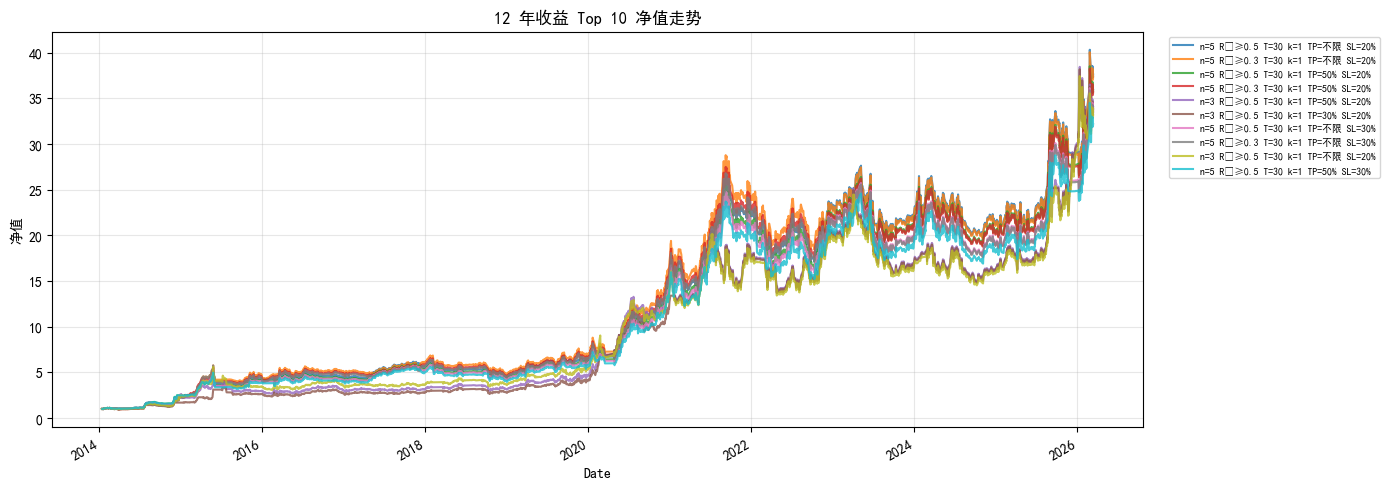

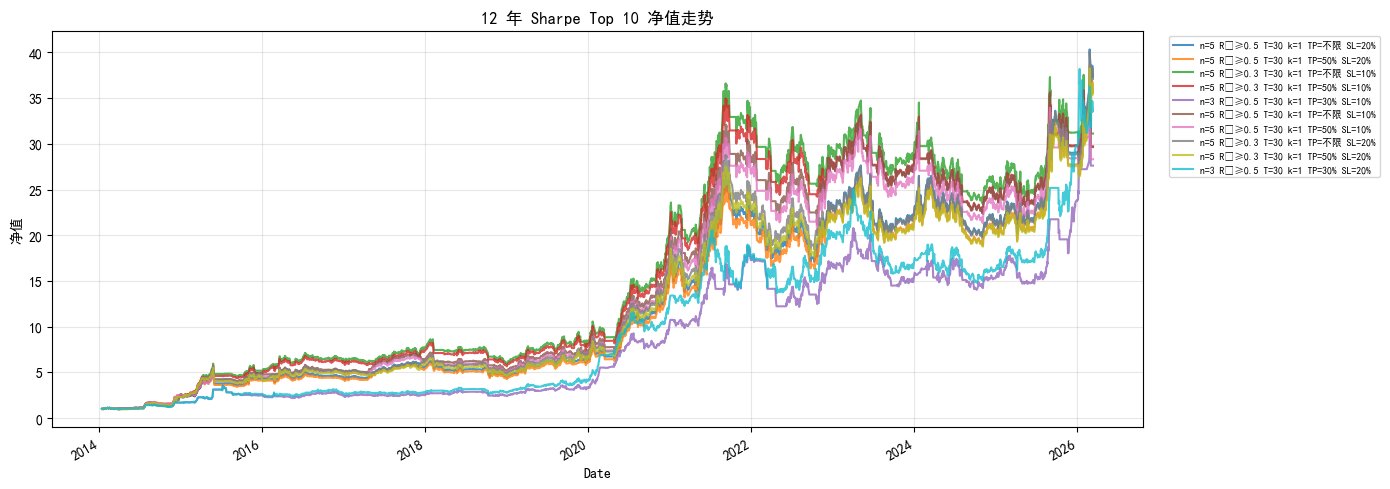

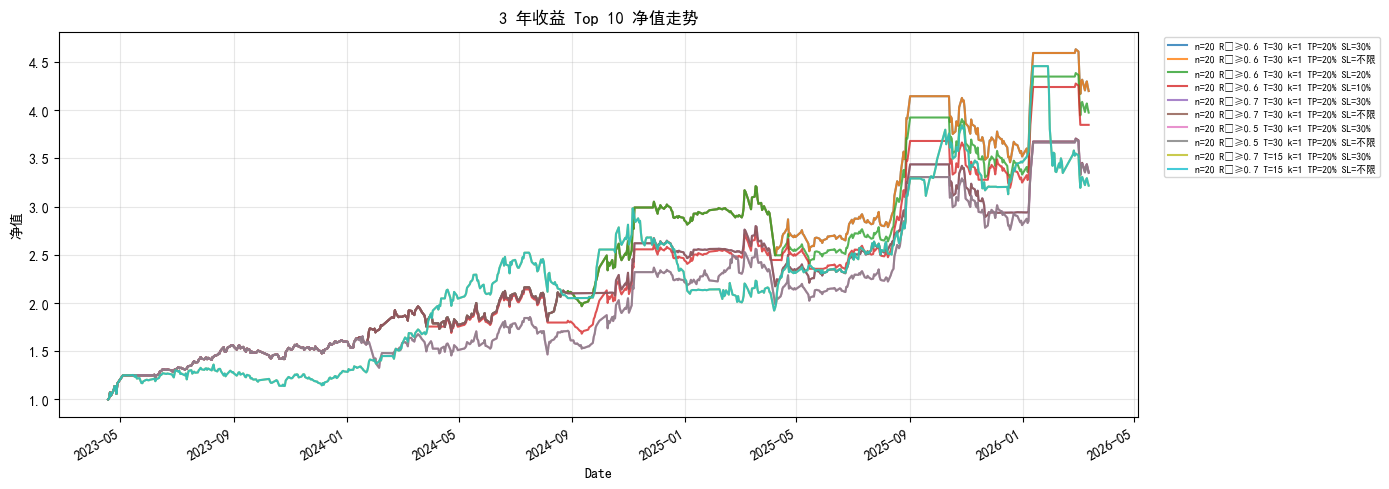

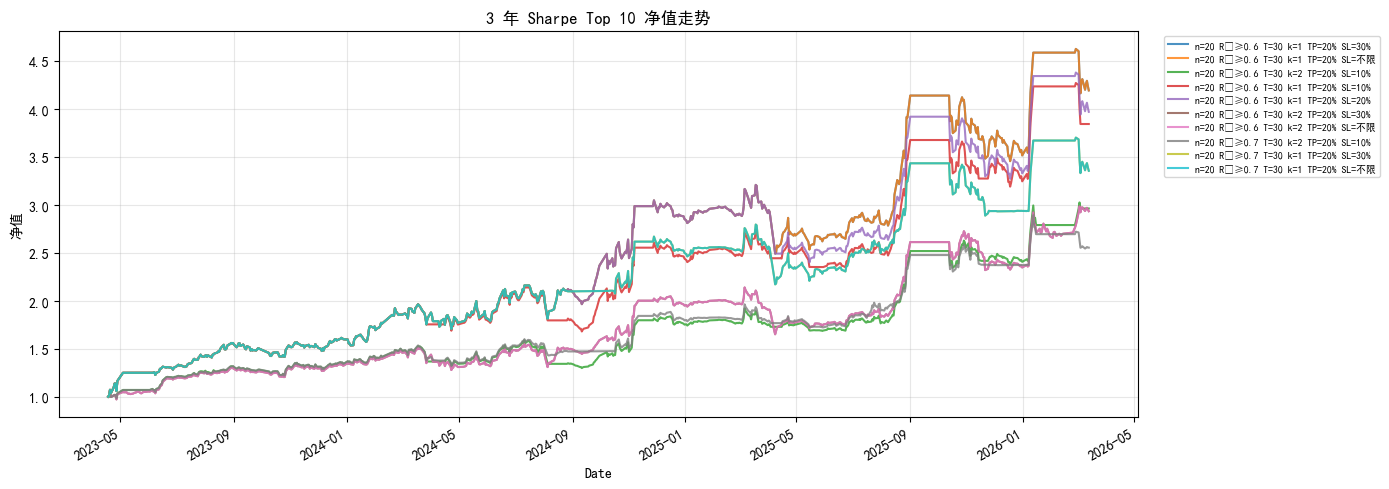

In [8]:
def _nav_key(row):
    n = int(row['n'])
    r2 = round(float(row['R2_threshold']), 4)
    rebal = int(row['rebal_period'])
    top_k = int(row['top_k'])
    tp = row.get('take_profit', None)
    sl = row.get('max_dd_stop', None)
    tp_s = 'inf' if pd.isna(tp) or tp is None else str(tp)
    sl_s = 'inf' if pd.isna(sl) or sl is None else str(sl)
    return f"n={n}_R2={r2}_rebal={rebal}_topk={top_k}_tp={tp_s}_sl={sl_s}"

import re

def _find_nav(cache, row):
    key = _nav_key(row)
    if key in cache:
        return cache[key]
    n, r2, rebal, top_k = int(row['n']), round(float(row['R2_threshold']), 4), int(row['rebal_period']), int(row['top_k'])
    tp = row.get('take_profit', None)
    sl = row.get('max_dd_stop', None)
    tp_s = 'inf' if pd.isna(tp) or tp is None else str(tp)
    sl_s = 'inf' if pd.isna(sl) or sl is None else str(sl)
    for k in cache:
        if (f"n={n}_" in k and f"_rebal={rebal}_" in k and f"_topk={top_k}" in k
                and f"_tp={tp_s}_" in k and f"_sl={sl_s}" in k):
            m = re.search(r'R2=([\d.]+)', k)
            if m and abs(float(m.group(1)) - r2) < 1e-5:
                return cache[k]
    return None

def _make_label(row):
    tp_s = f"{row['take_profit']:.0%}" if pd.notna(row.get('take_profit')) else '不限'
    sl_s = f"{row['max_dd_stop']:.0%}" if pd.notna(row.get('max_dd_stop')) else '不限'
    return f"n={int(row['n'])} R\u00b2\u2265{row['R2_threshold']} T={int(row['rebal_period'])} k={int(row['top_k'])} TP={tp_s} SL={sl_s}"

# 1) 12 年收益 Top 10 走势
top10_ret_12y = result_df.nlargest(10, 'total_ret_12y')
fig, ax = plt.subplots(figsize=(14, 5))
for _, row in top10_ret_12y.iterrows():
    nav = _find_nav(nav_cache, row)
    if nav is not None:
        nav.plot(ax=ax, label=_make_label(row), alpha=0.8)
ax.set_title('12 年收益 Top 10 净值走势'); ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7)
ax.set_ylabel('净值'); ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

# 2) 12 年 Sharpe Top 10 走势
top10_sharpe_12y = result_df.nlargest(10, 'sharpe_12y')
fig, ax = plt.subplots(figsize=(14, 5))
for _, row in top10_sharpe_12y.iterrows():
    nav = _find_nav(nav_cache, row)
    if nav is not None:
        nav.plot(ax=ax, label=_make_label(row), alpha=0.8)
ax.set_title('12 年 Sharpe Top 10 净值走势'); ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7)
ax.set_ylabel('净值'); ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

# 3) 3 年收益 Top 10 走势
top10_ret_3y = result_df.nlargest(10, 'total_ret_3y')
fig, ax = plt.subplots(figsize=(14, 5))
for _, row in top10_ret_3y.iterrows():
    nav = _find_nav(nav_cache_3y, row)
    if nav is not None:
        nav.plot(ax=ax, label=_make_label(row), alpha=0.8)
ax.set_title('3 年收益 Top 10 净值走势'); ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7)
ax.set_ylabel('净值'); ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

# 4) 3 年 Sharpe Top 10 走势
top10_sharpe_3y = result_df.nlargest(10, 'sharpe_3y')
fig, ax = plt.subplots(figsize=(14, 5))
for _, row in top10_sharpe_3y.iterrows():
    nav = _find_nav(nav_cache_3y, row)
    if nav is not None:
        nav.plot(ax=ax, label=_make_label(row), alpha=0.8)
ax.set_title('3 年 Sharpe Top 10 净值走势'); ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7)
ax.set_ylabel('净值'); ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

## 8. 四组 Top10 年收益表
上述四组 Top10 的逐年收益（12 年组为 2014–2026 年，3 年组为对应近 3 年年份）。

In [9]:
def _fmt_pct(s):
    return s.map(lambda x: f'{x:.2%}' if pd.notna(x) else '-')

def _fmt_tp_sl(df):
    df = df.copy()
    df['take_profit'] = df['take_profit'].map(lambda x: f'{x:.0%}' if pd.notna(x) else '不限')
    df['max_dd_stop'] = df['max_dd_stop'].map(lambda x: f'{x:.0%}' if pd.notna(x) else '不限')
    return df

param_cols = ['n', 'R2_threshold', 'rebal_period', 'top_k', 'take_profit', 'max_dd_stop']
summary_12y = ['annualized_12y', 'total_ret_12y', 'sharpe_12y', 'max_drawdown_12y']
summary_3y = ['annualized_3y', 'total_ret_3y', 'sharpe_3y', 'max_drawdown_3y']

# 1) 12 年收益 Top 10
print('【12 年收益 Top 10】年收益 + 汇总')
tbl = top10_ret_12y[param_cols + year_cols + summary_12y].copy()
tbl = _fmt_tp_sl(tbl)
for c in year_cols + ['annualized_12y', 'total_ret_12y', 'max_drawdown_12y']:
    tbl[c] = _fmt_pct(tbl[c])
tbl['sharpe_12y'] = tbl['sharpe_12y'].map(lambda x: f'{x:.2f}' if pd.notna(x) else '-')
tbl.index = range(1, len(tbl) + 1); tbl.index.name = '排名'
display(tbl)

# 2) 12 年 Sharpe Top 10
print('\n【12 年 Sharpe Top 10】年收益 + 汇总')
tbl2 = top10_sharpe_12y[param_cols + year_cols + summary_12y].copy()
tbl2 = _fmt_tp_sl(tbl2)
for c in year_cols + ['annualized_12y', 'total_ret_12y', 'max_drawdown_12y']:
    tbl2[c] = _fmt_pct(tbl2[c])
tbl2['sharpe_12y'] = tbl2['sharpe_12y'].map(lambda x: f'{x:.2f}' if pd.notna(x) else '-')
tbl2.index = range(1, len(tbl2) + 1); tbl2.index.name = '排名'
display(tbl2)

# 3) 3 年收益 Top 10
y3_cols = [c for c in result_df.columns if str(c).startswith('y') and '_3y' in str(c)]
if y3_cols:
    print('\n【3 年收益 Top 10】年收益 + 汇总')
    tbl3 = top10_ret_3y[param_cols + y3_cols + summary_3y].copy()
    tbl3 = _fmt_tp_sl(tbl3)
    for c in y3_cols + ['annualized_3y', 'total_ret_3y', 'max_drawdown_3y']:
        tbl3[c] = _fmt_pct(tbl3[c])
    tbl3['sharpe_3y'] = tbl3['sharpe_3y'].map(lambda x: f'{x:.2f}' if pd.notna(x) else '-')
    tbl3.columns = [c.replace('_3y', '').replace('y', '') if c.startswith('y') else c for c in tbl3.columns]
    tbl3.index = range(1, len(tbl3) + 1); tbl3.index.name = '排名'
    display(tbl3)

    print('\n【3 年 Sharpe Top 10】年收益 + 汇总')
    tbl4 = top10_sharpe_3y[param_cols + y3_cols + summary_3y].copy()
    tbl4 = _fmt_tp_sl(tbl4)
    for c in y3_cols + ['annualized_3y', 'total_ret_3y', 'max_drawdown_3y']:
        tbl4[c] = _fmt_pct(tbl4[c])
    tbl4['sharpe_3y'] = tbl4['sharpe_3y'].map(lambda x: f'{x:.2f}' if pd.notna(x) else '-')
    tbl4.columns = [c.replace('_3y', '').replace('y', '') if c.startswith('y') else c for c in tbl4.columns]
    tbl4.index = range(1, len(tbl4) + 1); tbl4.index.name = '排名'
    display(tbl4)

【12 年收益 Top 10】年收益 + 汇总


,n,R2_threshold,rebal_period,top_k,take_profit,max_dd_stop,2014,2015,2016,2017,...,2021,2022,2023,2024,2025,2026,annualized_12y,total_ret_12y,sharpe_12y,max_drawdown_12y
排名,,,,,,,,,,,,,,,,,,,,,
1,5,0.5,30,1,不限,20%,155.42%,68.96%,4.56%,24.00%,...,31.99%,3.29%,-4.07%,-6.57%,34.95%,29.53%,34.78%,3662.23%,1.13,-35.86%
2,5,0.3,30,1,不限,20%,136.94%,94.10%,21.68%,18.77%,...,31.99%,-5.05%,-4.07%,-6.57%,34.95%,29.53%,34.71%,3636.70%,1.12,-35.86%
3,5,0.5,30,1,50%,20%,148.62%,68.52%,4.56%,24.00%,...,31.99%,3.29%,-4.07%,-6.57%,34.95%,29.53%,34.27%,3493.84%,1.13,-35.86%
4,5,0.3,30,1,50%,20%,130.63%,93.60%,21.68%,18.77%,...,31.99%,-5.05%,-4.07%,-6.57%,34.95%,29.53%,34.20%,3469.45%,1.11,-35.86%
5,3,0.5,30,1,50%,20%,119.78%,36.34%,3.50%,3.02%,...,14.32%,13.58%,-16.52%,-5.76%,82.86%,12.86%,33.67%,3306.44%,1.07,-45.05%
6,3,0.5,30,1,30%,20%,68.90%,57.17%,3.50%,3.02%,...,30.18%,13.58%,-16.52%,-5.76%,83.04%,12.86%,33.59%,3282.76%,1.11,-40.64%
7,5,0.5,30,1,不限,30%,155.42%,57.37%,4.56%,24.00%,...,31.99%,3.29%,-7.74%,-6.57%,34.95%,29.53%,33.57%,3270.00%,1.10,-35.86%
8,5,0.3,30,1,不限,30%,136.94%,80.79%,21.68%,18.77%,...,31.99%,-5.05%,-7.74%,-6.57%,34.95%,29.53%,33.49%,3247.14%,1.08,-35.86%
9,3,0.5,30,1,不限,20%,130.31%,37.84%,3.50%,3.02%,...,14.32%,13.58%,-16.52%,-5.76%,82.86%,12.86%,33.37%,3216.83%,1.05,-45.05%



【12 年 Sharpe Top 10】年收益 + 汇总


,n,R2_threshold,rebal_period,top_k,take_profit,max_dd_stop,2014,2015,2016,2017,...,2021,2022,2023,2024,2025,2026,annualized_12y,total_ret_12y,sharpe_12y,max_drawdown_12y
排名,,,,,,,,,,,,,,,,,,,,,
1,5,0.5,30,1,不限,20%,155.42%,68.96%,4.56%,24.00%,...,31.99%,3.29%,-4.07%,-6.57%,34.95%,29.53%,34.78%,3662.23%,1.13,-35.86%
2,5,0.5,30,1,50%,20%,148.62%,68.52%,4.56%,24.00%,...,31.99%,3.29%,-4.07%,-6.57%,34.95%,29.53%,34.27%,3493.84%,1.13,-35.86%
3,5,0.3,30,1,不限,10%,144.63%,108.49%,25.35%,18.77%,...,45.20%,-10.16%,-0.57%,-14.95%,22.42%,-0.38%,32.70%,3013.06%,1.13,-35.97%
4,5,0.3,30,1,50%,10%,138.12%,107.95%,25.35%,18.77%,...,45.20%,-10.16%,-0.57%,-14.95%,22.42%,-0.38%,32.20%,2873.72%,1.12,-35.97%
5,3,0.5,30,1,30%,10%,68.89%,49.17%,-1.15%,3.02%,...,60.77%,-4.49%,-9.04%,-1.60%,54.08%,15.59%,31.38%,2662.41%,1.12,-38.68%
6,5,0.5,30,1,不限,10%,157.08%,87.78%,6.89%,24.00%,...,45.20%,-2.48%,-0.57%,-14.95%,22.42%,-0.38%,32.16%,2864.52%,1.12,-34.28%
7,5,0.5,30,1,50%,10%,150.23%,87.29%,6.89%,24.00%,...,45.20%,-2.48%,-0.57%,-14.95%,22.42%,-0.38%,31.67%,2731.83%,1.12,-34.28%
8,5,0.3,30,1,不限,20%,136.94%,94.10%,21.68%,18.77%,...,31.99%,-5.05%,-4.07%,-6.57%,34.95%,29.53%,34.71%,3636.70%,1.12,-35.86%
9,5,0.3,30,1,50%,20%,130.63%,93.60%,21.68%,18.77%,...,31.99%,-5.05%,-4.07%,-6.57%,34.95%,29.53%,34.20%,3469.45%,1.11,-35.86%



【3 年收益 Top 10】年收益 + 汇总


,n,R2_threshold,rebal_period,top_k,take_profit,max_dd_stop,2023,2024,2025,2026,annualized_3y,total_ret_3y,sharpe_3y,max_drawdown_3y
排名,,,,,,,,,,,,,,
1,20,0.6,30,1,20%,30%,60.02%,78.79%,23.96%,16.53%,63.94%,319.79%,1.72,-22.32%
2,20,0.6,30,1,20%,不限,60.02%,78.79%,23.96%,16.53%,63.94%,319.79%,1.72,-22.32%
3,20,0.6,30,1,20%,20%,60.02%,78.79%,17.36%,16.53%,60.88%,297.43%,1.66,-25.21%
4,20,0.6,30,1,20%,10%,60.02%,52.86%,33.86%,15.68%,59.08%,284.71%,1.69,-21.46%
5,20,0.7,30,1,20%,30%,60.02%,56.64%,18.22%,14.30%,51.82%,235.90%,1.55,-22.32%
6,20,0.7,30,1,20%,不限,60.02%,56.64%,18.22%,14.30%,51.82%,235.90%,1.55,-22.32%
7,20,0.5,30,1,20%,30%,60.02%,38.74%,27.44%,16.53%,51.66%,234.87%,1.43,-22.32%
8,20,0.5,30,1,20%,不限,60.02%,38.74%,27.44%,16.53%,51.66%,234.87%,1.43,-22.32%
9,20,0.7,15,1,20%,30%,29.06%,75.55%,55.12%,-8.46%,49.58%,221.73%,1.32,-35.57%



【3 年 Sharpe Top 10】年收益 + 汇总


,n,R2_threshold,rebal_period,top_k,take_profit,max_dd_stop,2023,2024,2025,2026,annualized_3y,total_ret_3y,sharpe_3y,max_drawdown_3y
排名,,,,,,,,,,,,,,
1,20,0.6,30,1,20%,30%,60.02%,78.79%,23.96%,16.53%,63.94%,319.79%,1.72,-22.32%
2,20,0.6,30,1,20%,不限,60.02%,78.79%,23.96%,16.53%,63.94%,319.79%,1.72,-22.32%
3,20,0.6,30,2,20%,10%,34.52%,28.07%,37.09%,21.73%,45.44%,196.55%,1.70,-18.27%
4,20,0.6,30,1,20%,10%,60.02%,52.86%,33.86%,15.68%,59.08%,284.71%,1.69,-21.46%
5,20,0.6,30,1,20%,20%,60.02%,78.79%,17.36%,16.53%,60.88%,297.43%,1.66,-25.21%
6,20,0.6,30,2,20%,30%,32.82%,44.44%,20.12%,23.56%,44.95%,193.70%,1.57,-22.83%
7,20,0.6,30,2,20%,不限,32.82%,44.44%,20.12%,23.56%,44.95%,193.70%,1.57,-22.83%
8,20,0.7,30,2,20%,10%,34.77%,31.05%,31.99%,7.58%,38.19%,155.67%,1.56,-13.95%
9,20,0.7,30,1,20%,30%,60.02%,56.64%,18.22%,14.30%,51.82%,235.90%,1.55,-22.32%


## 9. 最优参数调仓明细（自动取 Top1）

In [10]:
import json as _json
with open('etf_all.json') as _f:
    _etf_data = _json.load(_f)
etf_name_map = {item['symbol']: item['name'] for item in _etf_data['data']['list']}

_best = result_df.nlargest(1, 'annualized_12y').iloc[0]
BEST_N = int(_best['n'])
BEST_R2 = _best['R2_threshold']
BEST_REBAL = int(_best['rebal_period'])
BEST_TOPK = int(_best['top_k'])
BEST_TP = _best['take_profit'] if pd.notna(_best['take_profit']) else None
BEST_SL = _best['max_dd_stop'] if pd.notna(_best['max_dd_stop']) else None
tp_disp = f'{BEST_TP:.0%}' if BEST_TP is not None else '不限'
sl_disp = f'{BEST_SL:.0%}' if BEST_SL is not None else '不限'
print(f'从全量回测 Top1 提取最优参数: n={BEST_N}, R²≥{BEST_R2}, rebal={BEST_REBAL}, '
      f'top_k={BEST_TOPK}, 止盈={tp_disp}, 回撤止损={sl_disp}')
print(f'  年化收益={_best["annualized_12y"]:.2%}, 总收益={_best["total_ret_12y"]:.2%}, '
      f'Sharpe={_best["sharpe_12y"]:.2f}, 最大回撤={_best["max_drawdown_12y"]:.2%}')

slope, r2 = linreg_cache[BEST_N]
start_idx = BEST_N + 5
dates = daily_ret.index[start_idx:]
rebal_indices = list(range(0, len(dates), BEST_REBAL))

trades = []
cum = 1.0
prev_selected = []
entry_prices = {}
position_alive = {}
period_peak = 1.0
dd_stopped = False

for i, idx_pos in enumerate(rebal_indices):
    date = dates[idx_pos]
    s = slope.loc[date].dropna()
    r = r2.loc[date].dropna()
    common = s.index.intersection(r.index)
    s, r = s[common], r[common]

    candidates = s[r >= BEST_R2].sort_values(ascending=False)
    selected = candidates.head(BEST_TOPK).index.tolist() if len(candidates) >= 1 else []

    exec_idx = idx_pos + 1
    if exec_idx >= len(dates):
        break

    next_signal_idx = rebal_indices[i + 1] if i + 1 < len(rebal_indices) else len(dates) - 1
    next_exec_idx = next_signal_idx + 1

    signal_date = dates[idx_pos]
    exec_date = dates[exec_idx]

    any_dead = any(not position_alive.get(ss, True) for ss in prev_selected)
    changed = sorted(selected) != sorted(prev_selected) or dd_stopped or any_dead
    trade_cost = 0.0
    if changed:
        alive_old = [ss for ss in prev_selected if position_alive.get(ss, True)]
        if alive_old:
            trade_cost += COMMISSION * len(alive_old) / BEST_TOPK
        if selected:
            trade_cost += COMMISSION * len(selected) / BEST_TOPK
        cum *= (1 - trade_cost)

    if selected and changed:
        buy_prices = {}
        for sym in selected:
            op = panel_open.loc[exec_date, sym] if (exec_date in panel_open.index and sym in panel_open.columns) else panel.loc[exec_date, sym]
            buy_prices[sym] = op * (1 + SLIPPAGE)

        sell_prices = {}
        if next_exec_idx < len(dates):
            sell_date = dates[next_exec_idx]
            for sym in selected:
                op = panel_open.loc[sell_date, sym] if (sell_date in panel_open.index and sym in panel_open.columns) else panel.loc[sell_date, sym]
                sell_prices[sym] = op * (1 - SLIPPAGE)
        else:
            sell_date = dates[-1]
            for sym in selected:
                sell_prices[sym] = panel.loc[sell_date, sym]

        per_stock_rets = [(sell_prices[sym] / buy_prices[sym] - 1) for sym in selected]
        period_ret = np.mean(per_stock_rets)
        cum *= (1 + period_ret)

        buy_str = ','.join(f'{buy_prices[s]:.4f}' for s in selected)
        sell_str = ','.join(f'{sell_prices[s]:.4f}' for s in selected)
    else:
        period_ret = 0.0
        sell_date = dates[min(next_signal_idx, len(dates) - 1)]
        buy_str = '-'
        sell_str = '-'

    entry_prices = {sym: buy_prices[sym] for sym in selected} if selected and changed else entry_prices
    position_alive = {sym: True for sym in selected} if selected and changed else position_alive
    period_peak = cum if changed else period_peak
    dd_stopped = False

    prev_selected = selected

    tp_note = ''
    if BEST_TP is not None:
        tp_note = f'TP={BEST_TP:.0%}'
    if BEST_SL is not None:
        tp_note += f'{" " if tp_note else ""}SL={BEST_SL:.0%}'

    trades.append({
        '标的': ','.join(selected) if selected else '空仓',
        '名称': ','.join(etf_name_map.get(s, '-') for s in selected) if selected else '-',
        '信号日(T)': signal_date.strftime('%Y-%m-%d'),
        '执行日(T+1)': exec_date.strftime('%Y-%m-%d'),
        '买入价(open×1.001)': buy_str,
        '卖出日': sell_date.strftime('%Y-%m-%d'),
        '卖出价(open×0.999)': sell_str,
        '收益(卖/买-1)': f'{period_ret:.2%}',
        '手续费': f'{trade_cost:.4%}',
        '总净值': round(cum, 4),
        '风控': tp_note if tp_note else '-',
    })

trade_df = pd.DataFrame(trades)
trade_df.to_csv('trade_detail.csv', index=False, encoding='utf-8-sig')
print(f'共 {len(trade_df)} 次调仓，已导出 trade_detail.csv')
print(f'（注：明细表为调仓级别，止盈/止损的日内平仓已在回测净值中体现）')
display(trade_df)

从全量回测 Top1 提取最优参数: n=5, R²≥0.5, rebal=30, top_k=1, 止盈=不限, 回撤止损=20%
  年化收益=34.78%, 总收益=3662.23%, Sharpe=1.13, 最大回撤=-35.86%
共 99 次调仓，已导出 trade_detail.csv
（注：明细表为调仓级别，止盈/止损的日内平仓已在回测净值中体现）


,标的,名称,信号日(T),执行日(T+1),买入价(open×1.001),卖出日,卖出价(open×0.999),收益(卖/买-1),手续费,总净值,风控
0,SZ159915,创业板ETF易方达,2014-01-16,2014-01-17,1.3664,2014-03-07,1.4236,4.19%,0.0060%,1.0418,SL=20%
1,SH513500,标普500ETF博时,2014-03-06,2014-03-07,0.5205,2014-04-21,0.5165,-0.78%,0.0120%,1.0336,SL=20%
2,SH513500,标普500ETF博时,2014-04-18,2014-04-21,-,2014-06-04,-,0.00%,0.0000%,1.0336,SL=20%
3,SH510900,恒生中国企业ETF易方达,2014-06-04,2014-06-05,0.9059,2014-07-17,0.9441,4.21%,0.0120%,1.0770,SL=20%
4,SH510880,红利ETF华泰柏瑞,2014-07-16,2014-07-17,0.3143,2014-08-28,0.4346,38.26%,0.0120%,1.4889,SL=20%
...,...,...,...,...,...,...,...,...,...,...,...
94,SH515880,通信ETF,2025-08-21,2025-08-22,0.6937,2025-10-13,0.8322,19.96%,0.0120%,14.3616,SL=20%
95,SH560860,工业有色ETF万家,2025-10-10,2025-10-13,1.3794,2025-11-24,1.3287,-3.68%,0.0120%,13.8320,SL=20%
96,SZ159972,5年地债ETF,2025-11-21,2025-11-24,117.2692,2026-01-07,116.9020,-0.31%,0.0120%,13.7870,SL=20%
97,SH513310,中韩半导体ETF,2026-01-06,2026-01-07,3.1071,2026-02-26,4.0949,31.79%,0.0120%,18.1679,SL=20%


## 10. 当前应持仓标的（使用 Top1 最优参数）

In [11]:
latest_date = panel.index[-1]
s_now = slope.loc[latest_date].dropna()
r_now = r2.loc[latest_date].dropna()
common = s_now.index.intersection(r_now.index)
s_now, r_now = s_now[common], r_now[common]

candidates = s_now[r_now >= BEST_R2].sort_values(ascending=False)

tp_disp = f'{BEST_TP:.0%}' if BEST_TP is not None else '不限'
sl_disp = f'{BEST_SL:.0%}' if BEST_SL is not None else '不限'
print(f'策略参数: n={BEST_N}, R²≥{BEST_R2}, rebal={BEST_REBAL}, top_k={BEST_TOPK}, 止盈={tp_disp}, 回撤止损={sl_disp}')
print(f'信号日期: {latest_date.strftime("%Y-%m-%d")}')
print()

if len(candidates) >= 1:
    pick = candidates.head(BEST_TOPK)
    print('当前应持仓标的:')
    for sym, slp in pick.items():
        r2_val = r_now[sym]
        price = panel.loc[latest_date, sym]
        name = etf_name_map.get(sym, '')
        print(f'  {sym} {name}  斜率={slp:.6f}  R²={r2_val:.4f}  最新价={price:.4f}')
else:
    print('当前无标的通过筛选 → 空仓')

print()
print(f'所有通过 R²≥{BEST_R2} 筛选的候选标的 (共 {len(candidates)} 只):')
cand_df = pd.DataFrame({
    '标的': candidates.index,
    '名称': [etf_name_map.get(s, '') for s in candidates.index],
    '斜率': candidates.values,
    'R²': [r_now[s] for s in candidates.index],
    '最新价': [panel.loc[latest_date, s] for s in candidates.index],
}).reset_index(drop=True)
display(cand_df.head(20))

策略参数: n=5, R²≥0.5, rebal=30, top_k=1, 止盈=不限, 回撤止损=20%
信号日期: 2026-03-13

当前应持仓标的:
  SH515220 煤炭ETF  斜率=0.017506  R²=0.6191  最新价=1.3390

所有通过 R²≥0.5 筛选的候选标的 (共 77 只):


,标的,名称,斜率,R²,最新价
0,SH515220,煤炭ETF,0.017506,0.619073,1.339
1,SZ159790,碳中和ETF,0.016564,0.947581,0.865
2,SH516160,新能源ETF,0.015752,0.948016,3.284
3,SH516970,基建ETF广发,0.015746,0.978377,1.345
4,SZ159755,电池ETF,0.015438,0.941893,1.141
5,SZ159840,锂电池ETF工银,0.014663,0.934793,0.912
6,SH515030,新能源车ETF,0.012943,0.897935,1.936
7,SZ159611,电力ETF,0.011933,0.786251,1.192
8,SH562550,绿电ETF,0.011639,0.725708,1.292
9,SZ159761,新材料ETF国泰,0.009905,0.931096,0.814


## 11. 12-1 动量策略回测

> **⚠️ 需要先运行前面 §1~§4 的全部 Cell（加载数据、回测引擎、参数网格、批量回测）**

经典的 **Jegadeesh & Titman (1993)** 12-1 动量因子：

| 参数 | 值 | 学术依据 |
|------|------|----------|
| 回看窗口 | 252 日（12 个月） | 原始论文标准 |
| 跳过近期 | 21 日（1 个月） | 规避短期均值回复效应（short-term reversal） |
| R² 阈值 | ≥ 0.7 | 趋势质量过滤——R² 高意味着上涨趋势稳定线性，非随机波动 |
| 调仓周期 | 21 日（月频） | 与跳过期对齐，月度调仓是动量策略的标准频率 |
| 持仓数 top_k | 3 | ETF 轮动中 3 只提供适度分散，避免单只集中风险 |

上述参数固定不动，仅在**止盈 / 止损**上做网格搜索，观察风控对收益-回撤的影响。

12-1 动量信号计算完成: 回看252日跳过21日, 窗口231日
固定参数: R²≥0.7, 调仓21日, top_k=3
风控网格: 16 组 (4TP × 4SL)
12-1 策略回测完成, 耗时 25.0s

12-1 动量策略 (R²≥0.7, 调仓21日, top_k=3)
全部风控组合 (按 Sharpe 排序):


,take_profit,max_dd_stop,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026,avg_full_year,annualized,total_ret,sharpe,max_drawdown
排名,,,,,,,,,,,,,,,,,,,
1,20%,10%,86.73%,5.15%,23.52%,-17.27%,12.01%,31.52%,25.65%,-14.57%,-20.79%,9.80%,-4.33%,-4.47%,5.07%,8.99%,160.87%,0.56,-44.92%
2,不限,10%,76.91%,6.33%,23.52%,-17.27%,12.01%,34.64%,31.78%,-15.33%,-20.79%,9.80%,-3.67%,-4.47%,6.10%,9.33%,170.00%,0.56,-46.54%
3,50%,10%,76.91%,6.33%,23.52%,-17.27%,12.01%,34.64%,29.77%,-15.33%,-20.79%,9.80%,-3.67%,-4.47%,5.90%,9.17%,165.87%,0.55,-46.54%
4,30%,10%,72.44%,12.25%,23.52%,-17.27%,12.01%,32.77%,19.23%,-15.33%,-20.79%,9.80%,-3.67%,-4.47%,5.25%,8.48%,147.56%,0.52,-46.54%
5,20%,20%,24.99%,3.05%,27.85%,-15.85%,13.25%,46.35%,7.86%,-5.26%,-13.72%,13.52%,-6.78%,-2.14%,7.03%,7.09%,114.57%,0.43,-45.33%
6,30%,20%,21.98%,12.25%,27.85%,-15.85%,13.25%,48.28%,-0.27%,-6.37%,-13.72%,13.52%,-6.14%,-2.14%,7.28%,7.07%,114.13%,0.42,-44.67%
7,不限,30%,5.77%,4.20%,27.75%,-15.85%,13.25%,55.87%,7.44%,-5.11%,-13.72%,13.19%,-8.83%,4.98%,7.82%,7.00%,112.54%,0.41,-52.78%
8,50%,30%,8.64%,4.20%,27.75%,-15.85%,13.25%,55.87%,3.62%,-5.11%,-13.72%,13.19%,-8.83%,4.98%,7.44%,6.91%,110.55%,0.41,-52.78%
9,不限,20%,11.30%,4.20%,27.85%,-15.85%,13.25%,50.37%,12.78%,-6.37%,-13.72%,13.52%,-6.14%,-2.14%,7.99%,6.81%,108.23%,0.41,-50.32%


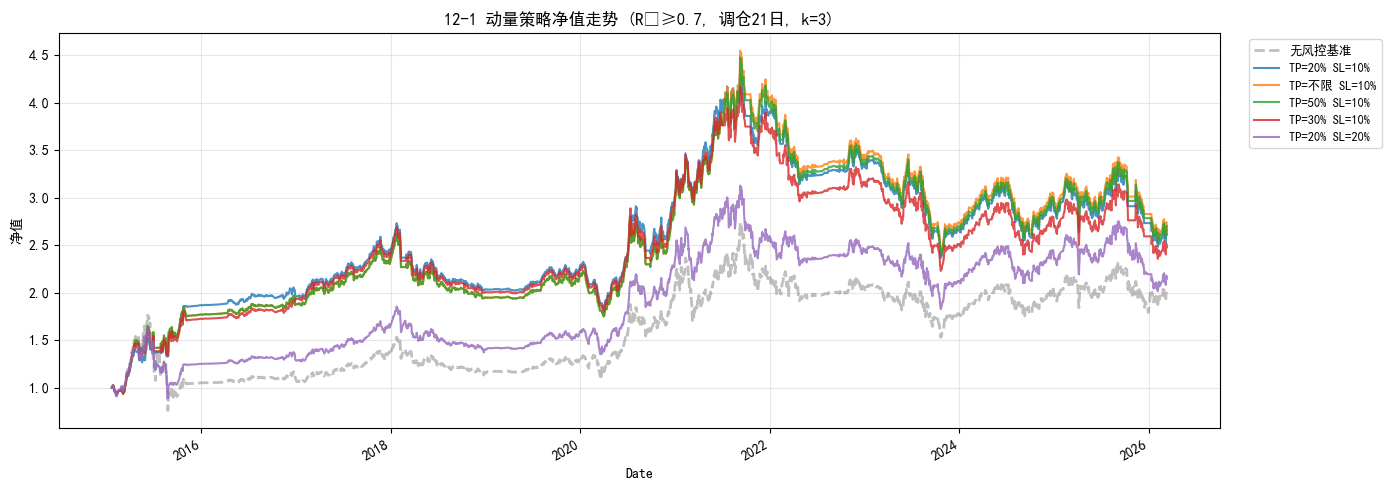


当前 12-1 信号 (2026-03-13):
  SH515880 通信ETF  斜率=0.005340  R²=0.8999  最新价=1.0850
  SZ159583 通信设备ETF  斜率=0.004912  R²=0.9095  最新价=1.3730
  SH560860 工业有色ETF万家  斜率=0.003985  R²=0.9158  最新价=1.8960


In [13]:
# ═══════════════════════════════════════════════════════════════
# 12-1 动量信号：回看12个月(252日)跳过最近1个月(21日)
# ═══════════════════════════════════════════════════════════════
LOOKBACK_12 = 252    # 12个月
SKIP_1M = 21         # 跳过最近1个月
WINDOW_12_1 = LOOKBACK_12 - SKIP_1M  # 实际窗口 231 天

R2_12_1 = 0.7        # 趋势质量过滤
REBAL_12_1 = 21      # 月频调仓
TOPK_12_1 = 3        # 持仓3只，适度分散

shifted_log_close = log_close.shift(SKIP_1M)
slope_12_1, r2_12_1 = rolling_linreg(shifted_log_close, WINDOW_12_1)
print(f'12-1 动量信号计算完成: 回看{LOOKBACK_12}日跳过{SKIP_1M}日, 窗口{WINDOW_12_1}日')
print(f'固定参数: R²≥{R2_12_1}, 调仓{REBAL_12_1}日, top_k={TOPK_12_1}')

# 仅在止盈/止损上做网格
tp_list_12_1 = [0.2, 0.3, 0.5, None]
sl_list_12_1 = [0.1, 0.2, 0.3, None]
grid_12_1 = list(product(tp_list_12_1, sl_list_12_1))
print(f'风控网格: {len(grid_12_1)} 组 ({len(tp_list_12_1)}TP × {len(sl_list_12_1)}SL)')

import time as _time
t0 = _time.time()

results_12_1 = []
nav_cache_12_1 = {}

for tp, sl_dd in grid_12_1:
    nav = backtest_momentum(
        slope_12_1, r2_12_1, daily_ret,
        n=LOOKBACK_12,
        r2_threshold=R2_12_1,
        rebal_period=REBAL_12_1,
        top_k=TOPK_12_1,
        take_profit=tp,
        max_dd_stop=sl_dd,
    )

    tp_s = 'inf' if tp is None else str(tp)
    sl_s = 'inf' if sl_dd is None else str(sl_dd)
    label = f'12-1_tp={tp_s}_sl={sl_s}'
    nav_cache_12_1[label] = nav

    years = sorted(nav.index.year.unique())
    annual_rets = {}
    for yr in years:
        yr_nav = nav[nav.index.year == yr]
        if len(yr_nav) < 10:
            continue
        annual_rets[yr] = yr_nav.iloc[-1] / yr_nav.iloc[0] - 1

    full_years = [y for y in annual_rets if y != years[0] and y != years[-1]]
    avg_ret = np.mean([annual_rets[y] for y in full_years]) if full_years else np.nan
    total_ret = nav.iloc[-1] / nav.iloc[0] - 1
    n_years = (nav.index[-1] - nav.index[0]).days / 365.25
    annualized = (1 + total_ret) ** (1 / n_years) - 1 if n_years > 0 else np.nan
    max_dd = ((nav / nav.cummax()) - 1).min()
    dr = nav.pct_change().dropna()
    sharpe = (dr.mean() / dr.std() * np.sqrt(252)) if dr.std() > 0 else np.nan

    row = {'take_profit': tp, 'max_dd_stop': sl_dd}
    row.update(annual_rets)
    row['avg_full_year'] = avg_ret
    row['annualized'] = annualized
    row['total_ret'] = total_ret
    row['sharpe'] = sharpe
    row['max_drawdown'] = max_dd
    results_12_1.append(row)

elapsed = _time.time() - t0
print(f'12-1 策略回测完成, 耗时 {elapsed:.1f}s')

df_12_1 = pd.DataFrame(results_12_1).sort_values('sharpe', ascending=False)

# ── 结果表 ──
yr_cols_12_1 = [c for c in df_12_1.columns if isinstance(c, (int, np.integer))]
disp = df_12_1.copy()
disp['take_profit'] = disp['take_profit'].map(lambda x: f'{x:.0%}' if pd.notna(x) else '不限')
disp['max_dd_stop'] = disp['max_dd_stop'].map(lambda x: f'{x:.0%}' if pd.notna(x) else '不限')
for c in yr_cols_12_1 + ['avg_full_year', 'annualized', 'total_ret', 'max_drawdown']:
    if c in disp.columns:
        disp[c] = disp[c].map(lambda x: f'{x:.2%}' if pd.notna(x) else '-')
disp['sharpe'] = disp['sharpe'].map(lambda x: f'{x:.2f}' if pd.notna(x) else '-')

print(f'\n12-1 动量策略 (R²≥{R2_12_1}, 调仓{REBAL_12_1}日, top_k={TOPK_12_1})')
print('全部风控组合 (按 Sharpe 排序):')
disp.index = range(1, len(disp) + 1); disp.index.name = '排名'
display(disp)

# ── 全部组合净值走势（按 Sharpe 前5 + 无风控基准）──
fig, ax = plt.subplots(figsize=(14, 5))

baseline_nav = nav_cache_12_1.get('12-1_tp=inf_sl=inf')
if baseline_nav is not None:
    baseline_nav.plot(ax=ax, label='无风控基准', color='gray', linewidth=2, alpha=0.5, linestyle='--')

for _, row in df_12_1.head(5).iterrows():
    tp = row['take_profit']; sl = row['max_dd_stop']
    tp_s = 'inf' if pd.isna(tp) else str(tp)
    sl_s = 'inf' if pd.isna(sl) else str(sl)
    lbl = f'12-1_tp={tp_s}_sl={sl_s}'
    nav = nav_cache_12_1.get(lbl)
    if nav is not None and lbl != '12-1_tp=inf_sl=inf':
        tp_d = f"{tp:.0%}" if pd.notna(tp) else '不限'
        sl_d = f"{sl:.0%}" if pd.notna(sl) else '不限'
        nav.plot(ax=ax, label=f'TP={tp_d} SL={sl_d}', alpha=0.8)

ax.set_title(f'12-1 动量策略净值走势 (R²≥{R2_12_1}, 调仓{REBAL_12_1}日, k={TOPK_12_1})')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
ax.set_ylabel('净值'); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# ── 当前持仓信号 ──
import json as _json
with open('etf_all.json') as _f:
    _etf_data = _json.load(_f)
_etf_name_map = {item['symbol']: item['name'] for item in _etf_data['data']['list']}

latest = panel.index[-1]
s121 = slope_12_1.loc[latest].dropna()
r121 = r2_12_1.loc[latest].dropna()
common = s121.index.intersection(r121.index)
s121, r121 = s121[common], r121[common]
cands = s121[r121 >= R2_12_1].sort_values(ascending=False)

print(f'\n当前 12-1 信号 ({latest.strftime("%Y-%m-%d")}):')
if len(cands) >= 1:
    pick = cands.head(TOPK_12_1)
    for sym, slp in pick.items():
        name = _etf_name_map.get(sym, '')
        print(f'  {sym} {name}  斜率={slp:.6f}  R²={r121[sym]:.4f}  最新价={panel.loc[latest, sym]:.4f}')
else:
    print('  无标的通过筛选 → 空仓')